In [3]:
!pip install torch torchvision torchaudio

In [6]:
!git clone https://github.com/bio-learn/biolearn.git
%cd biolearn
!pip install -e .

Cloning into 'biolearn'...
remote: Enumerating objects: 3476, done.
remote: Counting objects: 100% (1601/1601), done.
remote: Compressing objects: 100% (334/334), done.
remote: Total 3476 (delta 1384), reused 1269 (delta 1267), pack-reused 1875 (from 2)
Receiving objects: 100% (3476/3476), 53.42 MiB | 20.61 MiB/s, done.
Resolving deltas: 100% (2312/2312), done.
/content/biolearn
Obtaining file:///content/biolearn
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 5.3 MB/s eta 0:00:00
  Building editable for biolearn (pyproject.toml) ... done
  Created wheel for biolearn: filename=biolearn-0.9.2.dev6+g180852e2b-py3-none-any.whl size=4905 sha256=f2012e88766afc8a481e9079cbf3d6525028d975a878ced711c5ca2df5d3e17c
  Stored in directory: /

In [1]:
from biolearn.data_library import DataLibrary
print("Success! Bio-learn is installed correctly")

Success! Bio-learn is installed correctly


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from biolearn.data_library import DataLibrary
from biolearn.model_gallery import ModelGallery

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Initialize the DataLibrary
library = DataLibrary()

# Load Dataset 1: GSE41169 (Blood DNAm, 656 samples)
print("Loading GSE41169...")
dataset1_source = library.get("GSE41169")
dataset1 = dataset1_source.load()
print(f"✓ GSE41169 loaded: {len(dataset1.metadata)} samples")
print(f"  Age range: {dataset1.metadata['age'].min():.0f} - {dataset1.metadata['age'].max():.0f} years")
print(f"  Tissue: Blood (Illumina 450K array)")
print()

# Load Dataset 2: GSE120307 (Twin study) [citation:1]
print("Loading GSE120307...")
dataset2_source = library.get("GSE120307")
dataset2 = dataset2_source.load()
print(f"✓ GSE120307 loaded: {len(dataset2.metadata)} samples")
print(f"  Age range: {dataset2.metadata['age'].min():.0f} - {dataset2.metadata['age'].max():.0f} years")
print(f"  Tissue: Blood (Illumina 450K array)")

Loading GSE41169...
✓ GSE41169 loaded: 95 samples
  Age range: 18 - 65 years
  Tissue: Blood (Illumina 450K array)

Loading GSE120307...
✓ GSE120307 loaded: 34 samples
  Age range: 19 - 54 years
  Tissue: Blood (Illumina 450K array)


In [7]:
# Import properly
from biolearn.data_library import GeoData, DataLibrary
from biolearn.model_gallery import ModelGallery

# Load dataset
library = DataLibrary()
data = library.get("GSE41169").load()

# Get a model and predict
model = ModelGallery().get("Horvathv1")
predictions = model.predict(data)
print(predictions)

            Predicted
GSM1009660  30.452585
GSM1009661  24.820739
GSM1009662  65.401855
GSM1009663  23.173561
GSM1009664  32.450846
...               ...
GSM1009890  25.879032
GSM1009891  33.055429
GSM1009892  29.343783
GSM1009893  29.509558
GSM1009894  22.521523

[95 rows x 1 columns]


In [8]:
# Run all 8 models on dataset1
from biolearn.model_gallery import ModelGallery
from biolearn.data_library import DataLibrary
import pandas as pd
import numpy as np

# Load dataset
library = DataLibrary()
dataset1 = library.get("GSE41169").load()

# Define all 8 models with their imputation methods
model_configs = [
    ("Horvathv1", "averaging"),
    ("Hannum", "averaging"),
    ("PhenoAge", "averaging"),
    ("GrimAge2", "sesame_450k"),
    ("DunedinPACE", "dunedin"),
    ("Lin", "averaging"),
    ("Zhang_10", "averaging"),
    ("Horvathv2", "averaging")
]

# Store all predictions in a dictionary
all_predictions = {}

print("Running predictions on GSE41169...")
print("-" * 50)

for model_name, imp_method in model_configs:
    print(f"Running {model_name}...", end=" ")
    try:
        model = ModelGallery().get(model_name, imputation_method=imp_method)
        pred = model.predict(dataset1)

        # Get the prediction values
        if isinstance(pred, pd.DataFrame):
            values = pred.iloc[:, 0].values if len(pred.columns) > 0 else pred.values
        elif isinstance(pred, pd.Series):
            values = pred.values
        else:
            values = pred

        all_predictions[model_name] = values
        print(f"✓ Got {len(values)} predictions")

    except Exception as e:
        print(f"✗ Error: {str(e)[:50]}")
        all_predictions[model_name] = [np.nan] * len(dataset1.metadata)

print("\n" + "="*50)
print(f"Successfully ran {len([k for k,v in all_predictions.items() if not np.isnan(v).all()])} out of 8 models")

Running predictions on GSE41169...
--------------------------------------------------
Running Horvathv1... ✓ Got 95 predictions
Running Hannum... ✓ Got 95 predictions
Running PhenoAge... ✓ Got 95 predictions
Running GrimAge2... ✗ Error: 'Model not found: GrimAge2'
Running DunedinPACE... ✓ Got 95 predictions
Running Lin... ✓ Got 95 predictions
Running Zhang_10... ✓ Got 95 predictions
Running Horvathv2... ✓ Got 95 predictions

Successfully ran 7 out of 8 models


In [9]:
# Create a DataFrame with chronological age and all predictions
chron_age = dataset1.metadata['age'].values

df = pd.DataFrame({'ChronologicalAge': chron_age})

for model_name, pred_values in all_predictions.items():
    df[model_name] = pred_values

print("Complete DataFrame:")
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Complete DataFrame:
   ChronologicalAge  Horvathv1     Hannum   PhenoAge  GrimAge2  DunedinPACE  \
0              32.0  30.452585  35.009794  28.115610       NaN     1.203256   
1              24.0  24.820739  25.911236  19.577701       NaN     0.931709   
2              65.0  65.401855  65.536941  60.543320       NaN     1.290883   
3              25.0  23.173561  15.512122  11.743696       NaN     0.824050   
4              32.0  32.450846  31.191178  27.496016       NaN     1.019184   
5              30.0  29.027835  37.079390  27.690420       NaN     1.095508   
6              21.0  18.562688  25.763743  15.485208       NaN     0.923711   
7              21.0  23.090604  25.555333  16.959968       NaN     0.928703   
8              21.0  24.917391  21.686343  15.325059       NaN     0.845714   
9              24.0  15.749782  16.574560  18.307718       NaN     1.089632   

         Lin  Zhang_10  Horvathv2  
0  22.481143 -1.492555  31.937480  
1  15.589432 -2.446308  25.658929  
2 

In [10]:
# Check success rate of each model
print("\nModel Success Summary:")
print("-" * 40)
for model_name in all_predictions.keys():
    valid_count = df[model_name].notna().sum()
    valid_pct = (valid_count / len(df)) * 100
    if valid_pct > 50:
        print(f"✓ {model_name}: {valid_count}/{len(df)} predictions ({valid_pct:.0f}%)")
    else:
        print(f"✗ {model_name}: Only {valid_count}/{len(df)} predictions ({valid_pct:.0f}%) - SKIPPING")

# Keep only models that worked (at least 50% success)
working_models = [col for col in df.columns if col != 'ChronologicalAge' and df[col].notna().sum() > len(df)*0.5]
print(f"\n✅ Working models for visualization: {working_models}")


Model Success Summary:
----------------------------------------
✓ Horvathv1: 95/95 predictions (100%)
✓ Hannum: 95/95 predictions (100%)
✓ PhenoAge: 95/95 predictions (100%)
✗ GrimAge2: Only 0/95 predictions (0%) - SKIPPING
✓ DunedinPACE: 95/95 predictions (100%)
✓ Lin: 95/95 predictions (100%)
✓ Zhang_10: 95/95 predictions (100%)
✓ Horvathv2: 95/95 predictions (100%)

✅ Working models for visualization: ['Horvathv1', 'Hannum', 'PhenoAge', 'DunedinPACE', 'Lin', 'Zhang_10', 'Horvathv2']


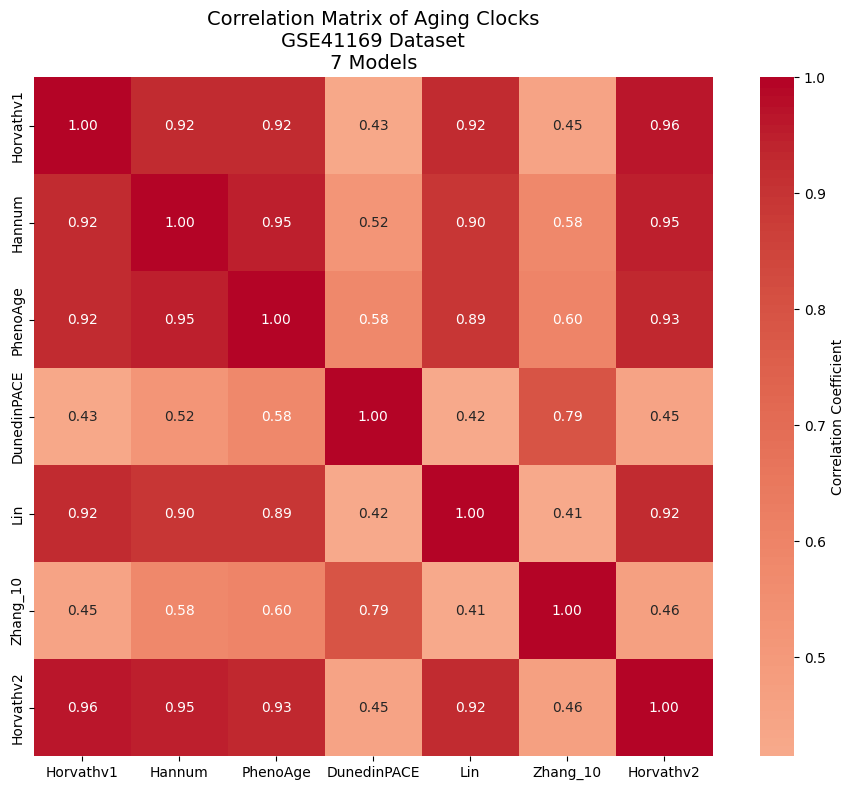

✓ Saved: correlation_matrix_dataset1.png


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter to working models only
df_filtered = df[['ChronologicalAge'] + working_models].copy()

# Calculate correlation matrix
corr_matrix = df_filtered[working_models].corr()

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, center=0,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title(f'Correlation Matrix of Aging Clocks\nGSE41169 Dataset\n{len(working_models)} Models', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix_dataset1.png', dpi=150)
plt.show()
print("✓ Saved: correlation_matrix_dataset1.png")

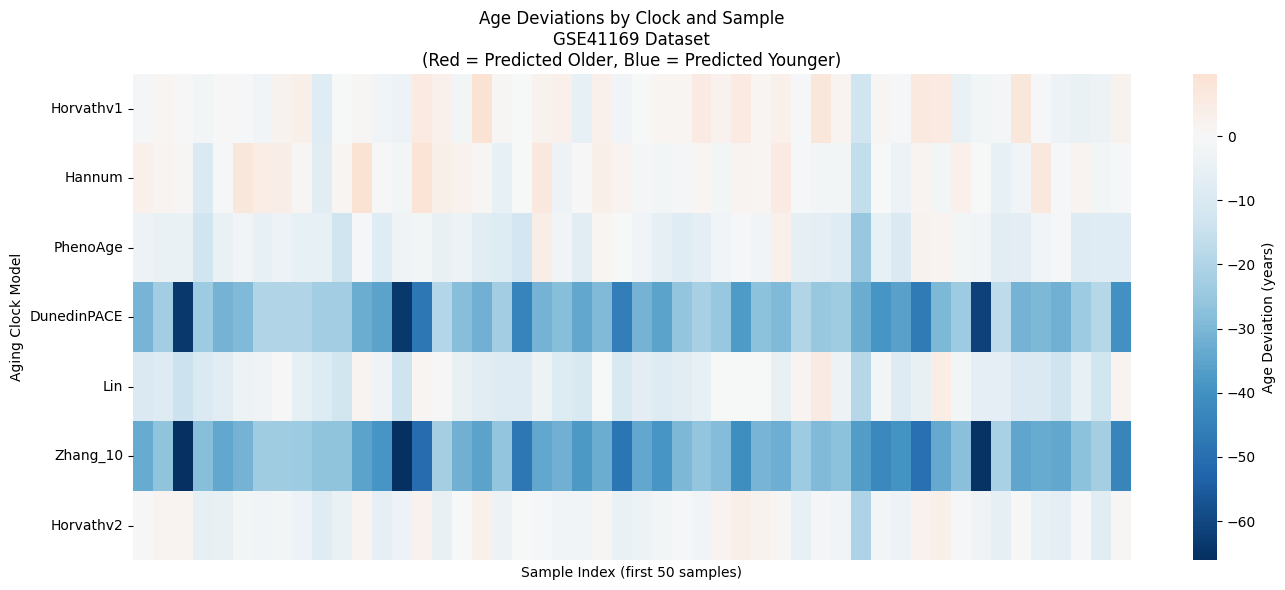

✓ Saved: deviation_heatmap_dataset1.png


In [12]:
# Calculate deviations (Predicted - Chronological Age)
deviation_data = {}
for model in working_models:
    deviation_data[model] = df_filtered[model] - df_filtered['ChronologicalAge']

deviation_df = pd.DataFrame(deviation_data).T  # Transpose so models are rows

# Plot (show first 50 samples for readability)
plt.figure(figsize=(14, max(6, len(working_models)*0.5)))
sns.heatmap(deviation_df.iloc[:, :50], cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Age Deviation (years)'},
            xticklabels=False)
plt.title(f'Age Deviations by Clock and Sample\nGSE41169 Dataset\n(Red = Predicted Older, Blue = Predicted Younger)',
          fontsize=12)
plt.ylabel('Aging Clock Model')
plt.xlabel('Sample Index (first 50 samples)')
plt.tight_layout()
plt.savefig('deviation_heatmap_dataset1.png', dpi=150)
plt.show()
print("✓ Saved: deviation_heatmap_dataset1.png")

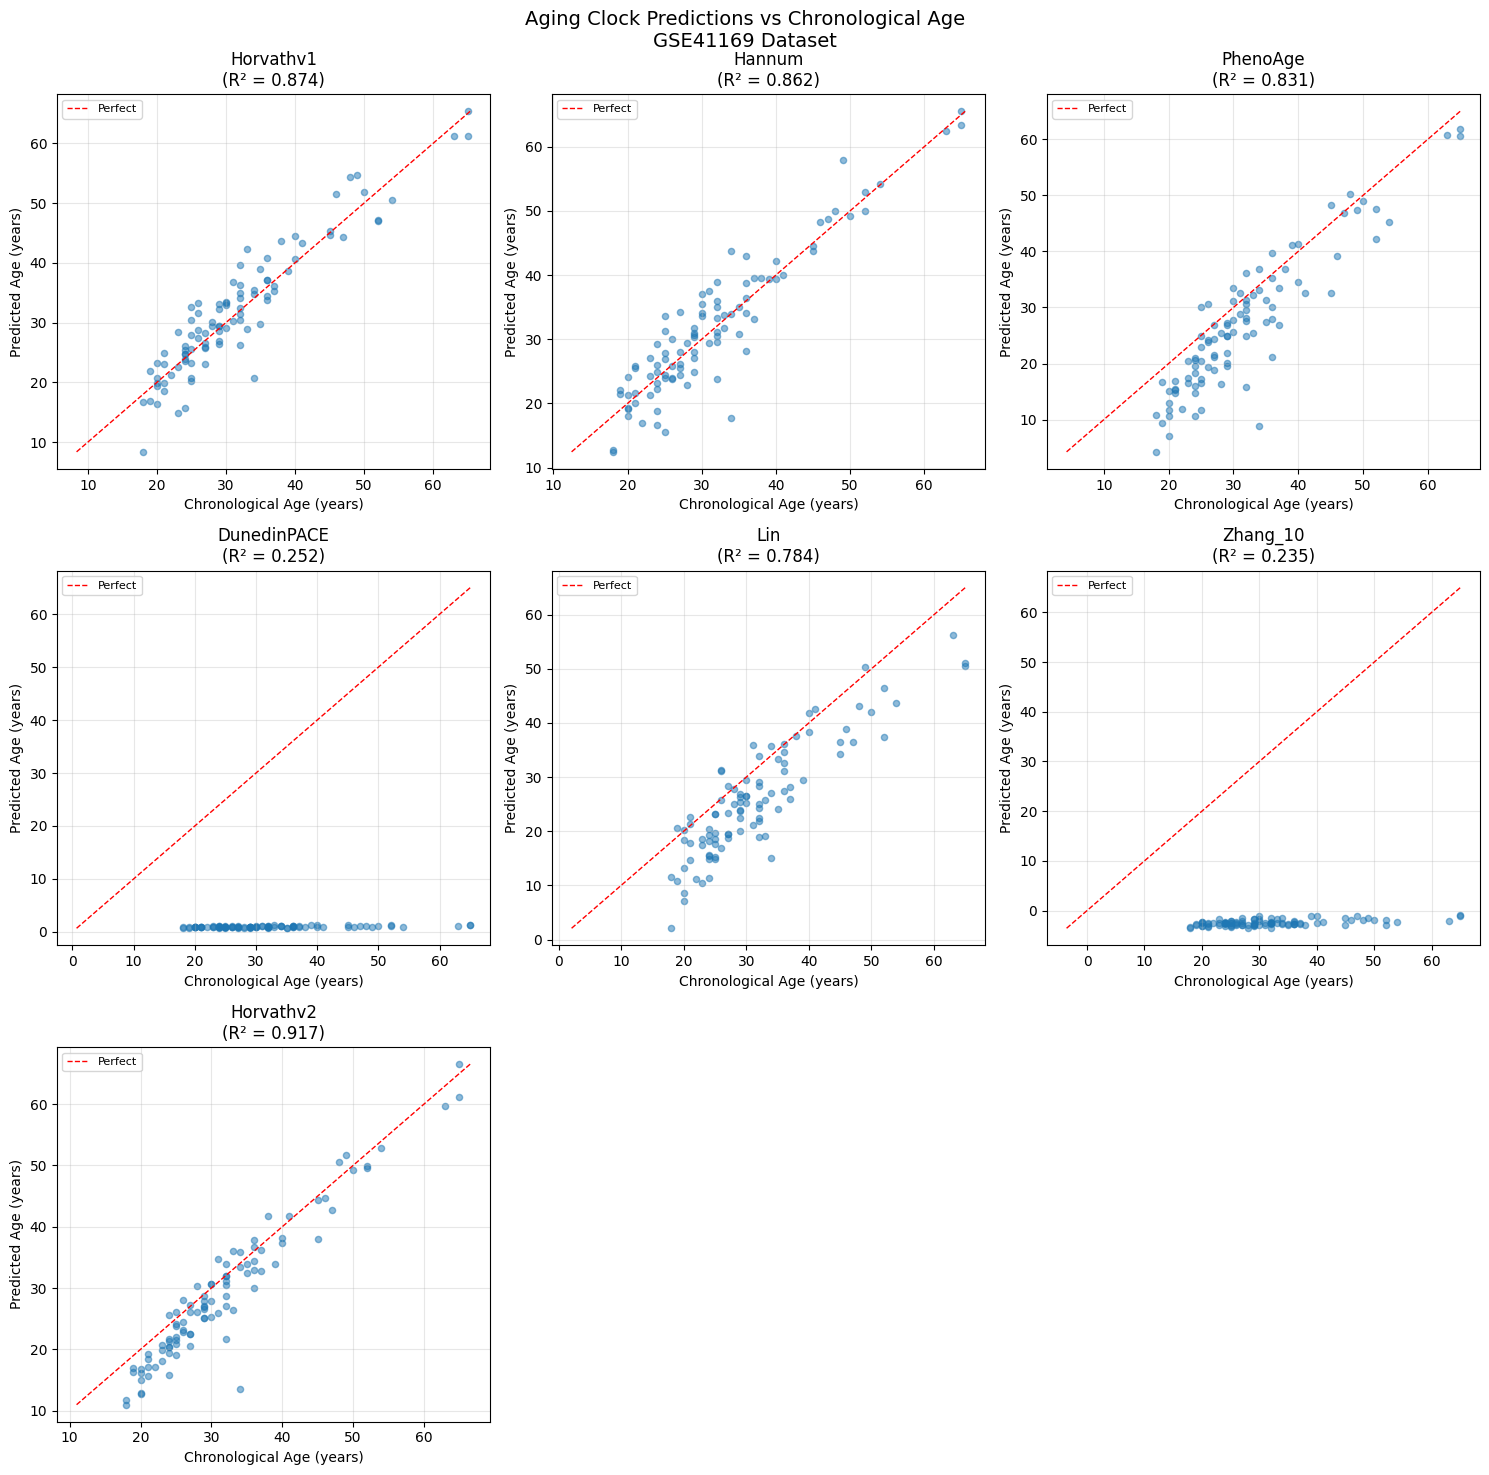

✓ Saved: predictions_vs_age_dataset1.png


In [13]:
# Calculate grid size for subplots
n_models = len(working_models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

chron_age = df_filtered['ChronologicalAge']

for i, model in enumerate(working_models):
    ax = axes[i]
    pred_age = df_filtered[model]

    # Remove NaN values
    mask = ~(chron_age.isna() | pred_age.isna())

    # Scatter plot
    ax.scatter(chron_age[mask], pred_age[mask], alpha=0.5, s=20)

    # Perfect prediction line
    age_min = min(chron_age.min(), pred_age.min())
    age_max = max(chron_age.max(), pred_age.max())
    ax.plot([age_min, age_max], [age_min, age_max], 'r--', label='Perfect', linewidth=1)

    # Calculate R²
    if mask.sum() > 1:
        corr = np.corrcoef(chron_age[mask], pred_age[mask])[0, 1]
        r2 = corr ** 2
    else:
        r2 = 0

    ax.set_xlabel('Chronological Age (years)')
    ax.set_ylabel('Predicted Age (years)')
    ax.set_title(f'{model}\n(R² = {r2:.3f})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Aging Clock Predictions vs Chronological Age\nGSE41169 Dataset', fontsize=14)
plt.tight_layout()
plt.savefig('predictions_vs_age_dataset1.png', dpi=150)
plt.show()
print("✓ Saved: predictions_vs_age_dataset1.png")

DATASET 2 - CORRELATION MATRIX
Models with valid predictions: ['Horvathv1', 'Hannum', 'PhenoAge', 'DunedinPACE', 'Lin', 'Zhang_10', 'Horvathv2']


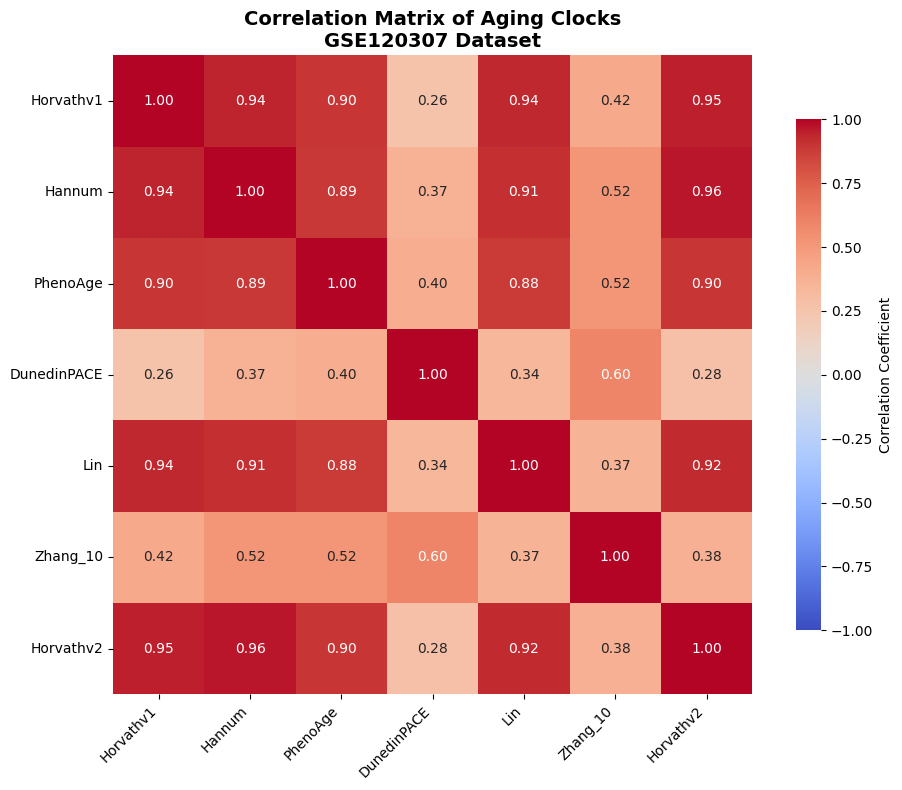

✓ Saved: correlation_matrix_dataset2.png

📊 Key Correlations:
   Horvathv1 vs Hannum: 0.943
   Horvathv1 vs PhenoAge: 0.896
   Horvathv1 vs DunedinPACE: 0.262
   Horvathv1 vs Lin: 0.937
   Horvathv1 vs Zhang_10: 0.415
   Horvathv1 vs Horvathv2: 0.953
   Hannum vs PhenoAge: 0.886
   Hannum vs DunedinPACE: 0.369
   Hannum vs Lin: 0.911
   Hannum vs Zhang_10: 0.520
   Hannum vs Horvathv2: 0.965
   PhenoAge vs DunedinPACE: 0.398
   PhenoAge vs Lin: 0.876
   PhenoAge vs Zhang_10: 0.517
   PhenoAge vs Horvathv2: 0.898
   DunedinPACE vs Lin: 0.336
   DunedinPACE vs Zhang_10: 0.598
   DunedinPACE vs Horvathv2: 0.277
   Lin vs Zhang_10: 0.365
   Lin vs Horvathv2: 0.923
   Zhang_10 vs Horvathv2: 0.379


In [15]:
# VISUALIZATION 1: Correlation Matrix for Dataset 2
import matplotlib.pyplot as plt
import seaborn as sns

print("="*50)
print("DATASET 2 - CORRELATION MATRIX")
print("="*50)

# Check which models have valid predictions
valid_models = []
for model in working_models2:
    if df2[model].notna().sum() > len(df2) * 0.5:
        valid_models.append(model)

print(f"Models with valid predictions: {valid_models}")

if len(valid_models) >= 2:
    # Calculate correlation matrix
    corr_matrix = df2[valid_models].corr()

    # Create heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix,
                annot=True,           # Show numbers in cells
                fmt='.2f',            # 2 decimal places
                cmap='coolwarm',      # Red = positive, Blue = negative
                square=True,          # Square cells
                center=0,             # Center colormap at 0
                vmin=-1, vmax=1,      # Correlation range
                cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8})

    plt.title('Correlation Matrix of Aging Clocks\nGSE120307 Dataset',
              fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('correlation_matrix_dataset2.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✓ Saved: correlation_matrix_dataset2.png")

    # Print correlation values for report
    print("\n📊 Key Correlations:")
    for i in range(len(valid_models)):
        for j in range(i+1, len(valid_models)):
            corr = corr_matrix.iloc[i, j]
            print(f"   {valid_models[i]} vs {valid_models[j]}: {corr:.3f}")
else:
    print(f"❌ Need at least 2 working models. Only found {len(valid_models)}")

DATASET 2 - AGE DEVIATION HEATMAP
Models included: ['Horvathv1', 'Hannum', 'PhenoAge', 'DunedinPACE', 'Lin', 'Zhang_10', 'Horvathv2']


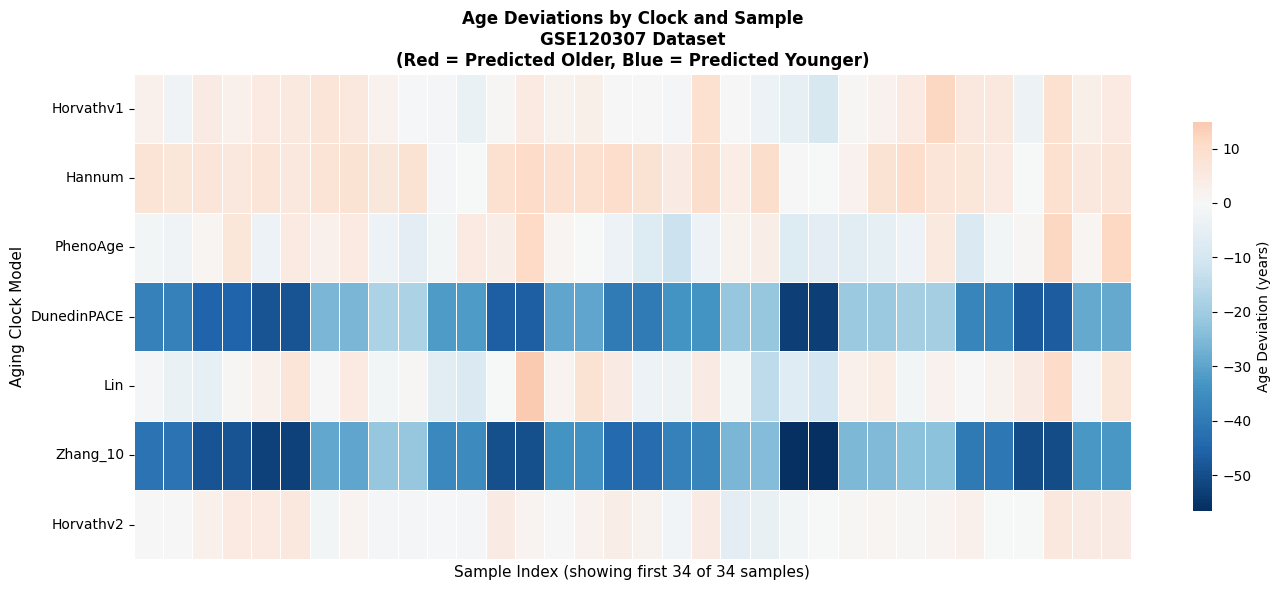

✓ Saved: deviation_heatmap_dataset2.png

📊 Deviation Summary (years):
   Horvathv1: Mean = 2.19 ± 4.44
   Hannum: Mean = 6.35 ± 3.34
   PhenoAge: Mean = -0.21 ± 5.89
   DunedinPACE: Mean = -34.57 ± 10.99
   Lin: Mean = 0.39 ± 5.96
   Zhang_10: Mean = -38.27 ± 10.86
   Horvathv2: Mean = 1.17 ± 2.88


In [16]:
# VISUALIZATION 2: Age Deviation Heatmap for Dataset 2
print("="*50)
print("DATASET 2 - AGE DEVIATION HEATMAP")
print("="*50)

# Use only valid models
valid_models = [col for col in working_models2 if df2[col].notna().sum() > len(df2) * 0.5]
print(f"Models included: {valid_models}")

if len(valid_models) >= 1:
    # Calculate deviations (Predicted - Chronological Age)
    deviations = {}
    for model in valid_models:
        deviations[model] = df2[model] - df2['ChronologicalAge']

    # Create DataFrame with models as rows, samples as columns
    dev_df = pd.DataFrame(deviations)
    dev_df_T = dev_df.T  # Transpose so models are rows

    # Limit to first 50 samples for readability
    max_samples = min(50, len(df2))
    dev_plot_data = dev_df_T.iloc[:, :max_samples]

    # Create heatmap
    fig_height = max(6, len(valid_models) * 0.6)
    plt.figure(figsize=(14, fig_height))

    sns.heatmap(dev_plot_data,
                cmap='RdBu_r',        # Red-Blue colormap
                center=0,              # Zero deviation = white
                cbar_kws={'label': 'Age Deviation (years)', 'shrink': 0.8},
                xticklabels=False,     # Hide sample labels (too many)
                linewidths=0.5,        # Thin lines between cells
                linecolor='white')

    plt.title('Age Deviations by Clock and Sample\nGSE120307 Dataset\n(Red = Predicted Older, Blue = Predicted Younger)',
              fontsize=12, fontweight='bold')
    plt.ylabel('Aging Clock Model', fontsize=11)
    plt.xlabel(f'Sample Index (showing first {max_samples} of {len(df2)} samples)', fontsize=11)
    plt.tight_layout()
    plt.savefig('deviation_heatmap_dataset2.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✓ Saved: deviation_heatmap_dataset2.png")

    # Summary statistics for report
    print("\n📊 Deviation Summary (years):")
    for model in valid_models:
        mean_dev = deviations[model].mean()
        std_dev = deviations[model].std()
        print(f"   {model}: Mean = {mean_dev:.2f} ± {std_dev:.2f}")
else:
    print("❌ No valid models found")

DATASET 2 - PREDICTIONS VS AGE SCATTER PLOTS
Models included: ['Horvathv1', 'Hannum', 'PhenoAge', 'DunedinPACE', 'Lin', 'Zhang_10', 'Horvathv2']


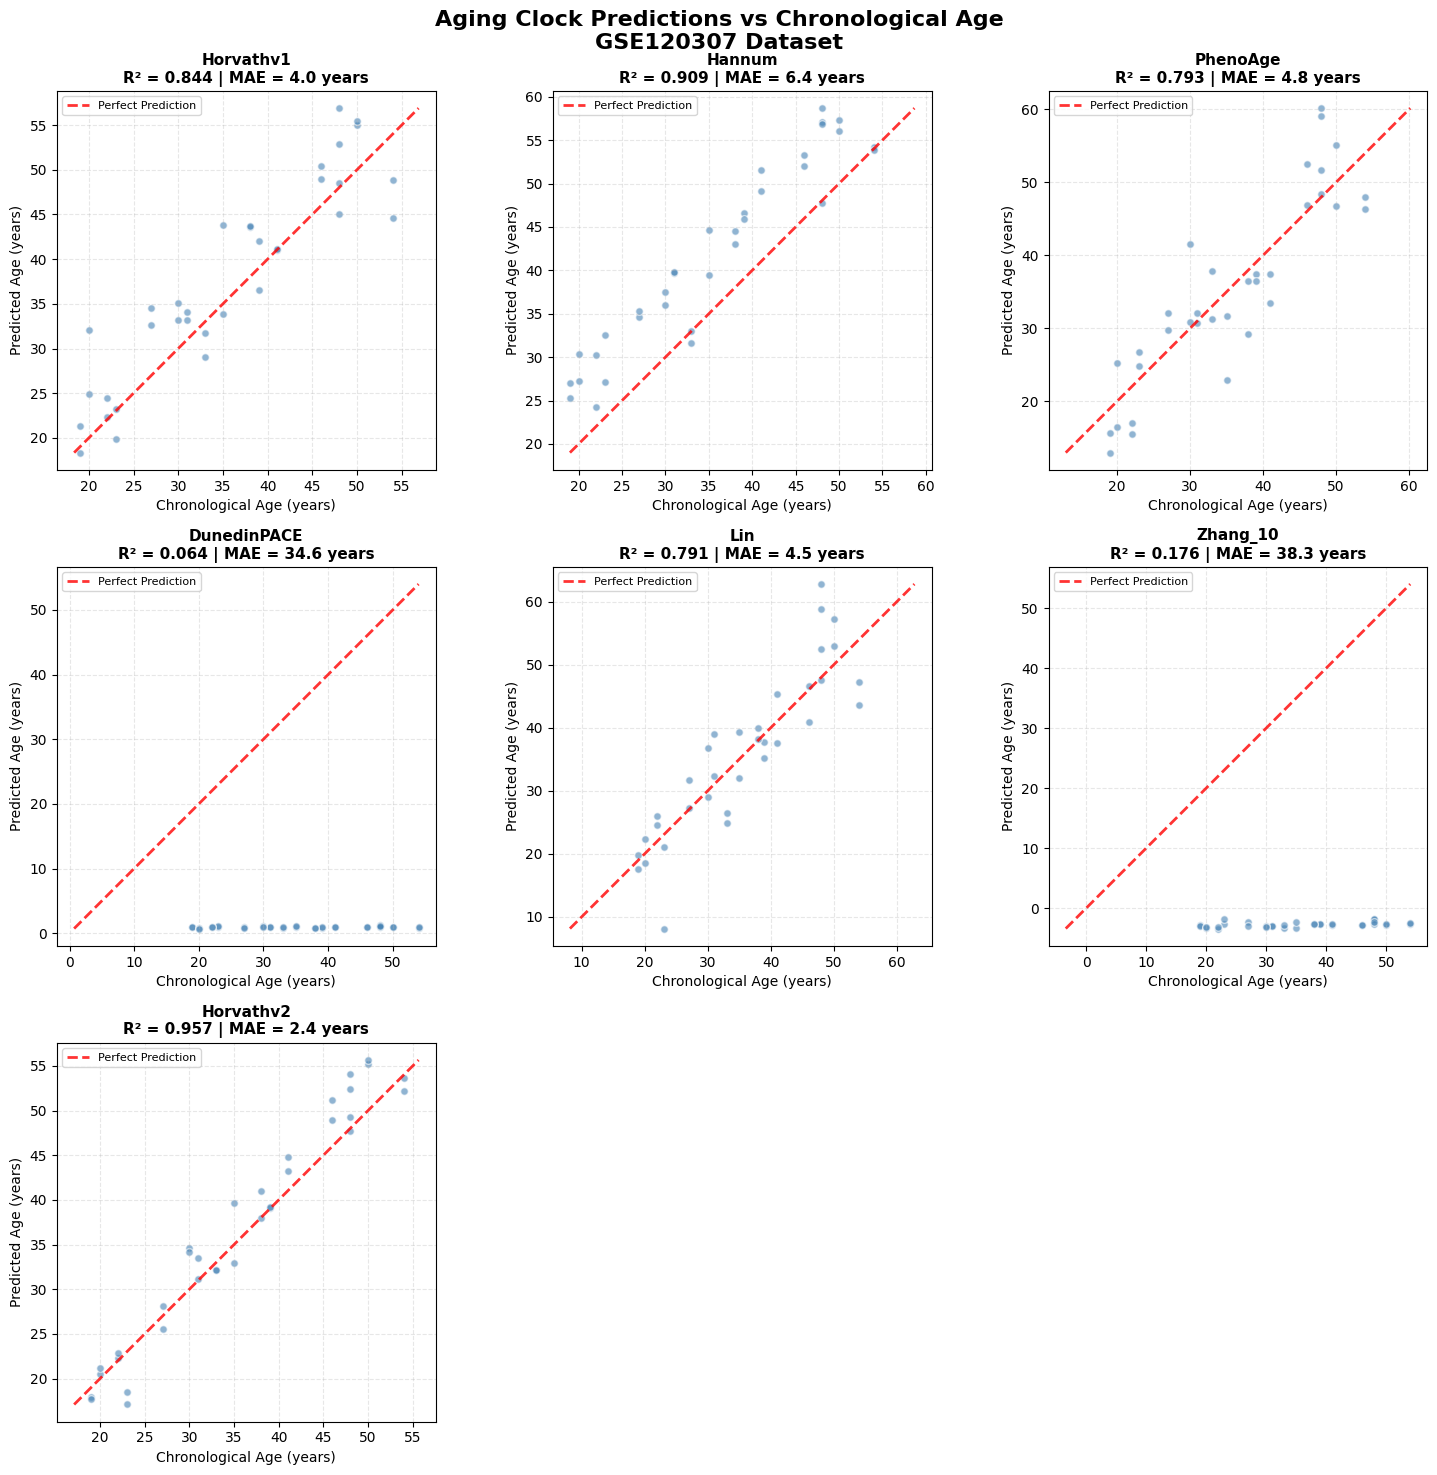

✓ Saved: predictions_vs_age_dataset2.png

📊 Model Performance Summary:
------------------------------------------------------------
Model           R²         MAE (years)     Samples   
------------------------------------------------------------
Horvathv1       0.844      4.0             34        
Hannum          0.909      6.4             34        
PhenoAge        0.793      4.8             34        
DunedinPACE     0.064      34.6            34        
Lin             0.791      4.5             34        
Zhang_10        0.176      38.3            34        
Horvathv2       0.957      2.4             34        
------------------------------------------------------------


In [17]:
# VISUALIZATION 3: Predictions vs Chronological Age for Dataset 2
print("="*50)
print("DATASET 2 - PREDICTIONS VS AGE SCATTER PLOTS")
print("="*50)

# Use only valid models
valid_models = [col for col in working_models2 if df2[col].notna().sum() > len(df2) * 0.5]
print(f"Models included: {valid_models}")

if len(valid_models) >= 1:
    # Calculate grid size for subplots
    n_models = len(valid_models)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols

    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))

    # Flatten axes array for easy indexing
    if n_models > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    chron_age = df2['ChronologicalAge']

    for i, model in enumerate(valid_models):
        ax = axes_flat[i]
        pred_age = df2[model]

        # Remove NaN values for plotting
        mask = ~(chron_age.isna() | pred_age.isna())
        x_plot = chron_age[mask]
        y_plot = pred_age[mask]

        # Scatter plot
        ax.scatter(x_plot, y_plot, alpha=0.6, s=30, c='steelblue', edgecolors='white')

        # Perfect prediction line (y = x)
        min_age = min(x_plot.min(), y_plot.min())
        max_age = max(x_plot.max(), y_plot.max())
        ax.plot([min_age, max_age], [min_age, max_age], 'r--',
                linewidth=2, label='Perfect Prediction', alpha=0.8)

        # Calculate R² (coefficient of determination)
        if len(x_plot) > 1:
            correlation = np.corrcoef(x_plot, y_plot)[0, 1]
            r_squared = correlation ** 2
        else:
            r_squared = 0

        # Calculate Mean Absolute Error
        mae = np.mean(np.abs(y_plot - x_plot))

        # Add labels and title
        ax.set_xlabel('Chronological Age (years)', fontsize=10)
        ax.set_ylabel('Predicted Age (years)', fontsize=10)
        ax.set_title(f'{model}\nR² = {r_squared:.3f} | MAE = {mae:.1f} years',
                     fontsize=11, fontweight='bold')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3, linestyle='--')

        # Set equal aspect ratio
        ax.set_aspect('equal', adjustable='box')

    # Hide unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Main title
    plt.suptitle('Aging Clock Predictions vs Chronological Age\nGSE120307 Dataset',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('predictions_vs_age_dataset2.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✓ Saved: predictions_vs_age_dataset2.png")

    # Summary table for report
    print("\n📊 Model Performance Summary:")
    print("-" * 60)
    print(f"{'Model':<15} {'R²':<10} {'MAE (years)':<15} {'Samples':<10}")
    print("-" * 60)
    for model in valid_models:
        pred_age = df2[model]
        mask = ~(chron_age.isna() | pred_age.isna())
        if mask.sum() > 1:
            r2 = np.corrcoef(chron_age[mask], pred_age[mask])[0, 1] ** 2
            mae = np.mean(np.abs(pred_age[mask] - chron_age[mask]))
            print(f"{model:<15} {r2:<10.3f} {mae:<15.1f} {mask.sum():<10}")
    print("-" * 60)
else:
    print("❌ No valid models found")